In [ ]:
!pip install -q gradio

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import gradio as gr

In [ ]:
!pip install -q kagglehub

import kagglehub
import os

# Download Twitter US Airline Sentiment dataset
path = kagglehub.dataset_download(
    "crowdflower/twitter-airline-sentiment"
)

print("Dataset downloaded to:", path)

# Show files inside dataset folder
print(os.listdir(path))

100%|██████████| 2.55M/2.55M [00:00<00:00, 95.5MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/crowdflower/twitter-airline-sentiment/versions/4
['Tweets.csv', 'database.sqlite']


In [ ]:
import pandas as pd
import os

csv_path = os.path.join(path, "Tweets.csv")

df = pd.read_csv(csv_path)

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [ ]:
df = df[['text', 'airline_sentiment']]

df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [ ]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Counts:")
print(df['airline_sentiment'].value_counts())

Dataset Shape: (14640, 2)

Missing Values:
text                 0
airline_sentiment    0
dtype: int64

Sentiment Counts:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


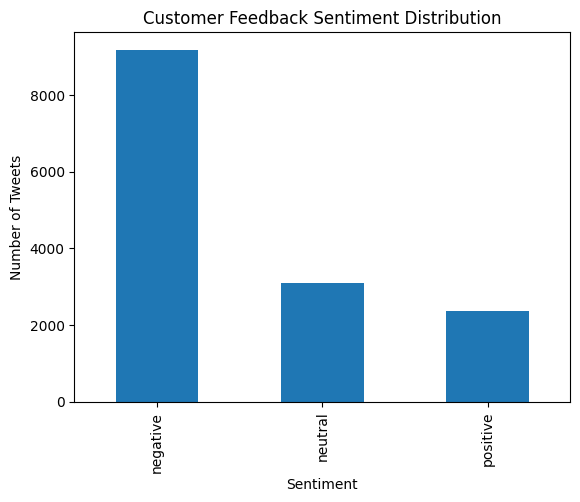

In [ ]:
df['airline_sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Customer Feedback Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

In [ ]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove Twitter mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags symbol
    text = re.sub(r"#", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


In [ ]:
X = df['clean_text']
y = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 11712
Testing samples: 2928


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(11712, 5000)


In [ ]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model Training Completed!")

Model Training Completed!


In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 76.95 %


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    negative       0.79      0.94      0.86      1835
     neutral       0.63      0.42      0.51       620
    positive       0.82      0.56      0.66       473

    accuracy                           0.77      2928
   macro avg       0.74      0.64      0.68      2928
weighted avg       0.76      0.77      0.75      2928



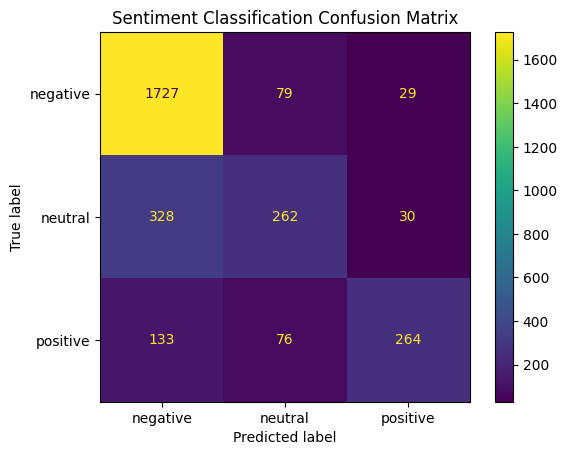

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Sentiment Classification Confusion Matrix")

plt.show()

In [ ]:
def predict_sentiment(feedback):

    cleaned = clean_text(feedback)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)[0]

    probabilities = model.predict_proba(vector)[0]

    confidence = max(probabilities) * 100

    if prediction == "positive":
        emoji = "😊"

    elif prediction == "negative":
        emoji = "😞"

    else:
        emoji = "😐"

    return f"{prediction.upper()} {emoji}\nConfidence: {confidence:.2f}%"

Test the model


In [ ]:
predict_sentiment(
    "The flight was excellent and the staff were very helpful"
)

'POSITIVE 😊\nConfidence: 77.19%'

In [ ]:
predict_sentiment(
    "My flight was delayed for five hours and nobody helped me"
)

'NEGATIVE 😞\nConfidence: 98.23%'

In [ ]:
def detect_complaint(text):

    text = text.lower()

    complaint_topics = {

        "Flight Delay":
        ["delay", "delayed", "late"],

        "Baggage":
        ["baggage", "bag", "luggage"],

        "Customer Service":
        ["staff", "service", "support", "customer service"],

        "Cancellation":
        ["cancelled", "canceled", "cancellation"],

        "Booking":
        ["booking", "reservation", "ticket"]
    }

    detected = []

    for topic, keywords in complaint_topics.items():

        for keyword in keywords:

            if keyword in text:
                detected.append(topic)
                break

    if len(detected) == 0:
        return "No specific complaint detected"

    return ", ".join(detected)

In [ ]:
def analyse_feedback(feedback):

    cleaned = clean_text(feedback)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)[0]

    probabilities = model.predict_proba(vector)[0]

    confidence = max(probabilities) * 100

    complaint = detect_complaint(feedback)

    if prediction == "positive":
        emoji = "😊"

    elif prediction == "negative":
        emoji = "😞"

    else:
        emoji = "😐"

    result = f"""
Sentiment: {prediction.upper()} {emoji}

Confidence: {confidence:.2f}%

Complaint Category: {complaint}
"""

    return result

In [ ]:
analyse_feedback(
    "My flight was delayed for 4 hours and my baggage was also lost."
)

'\nSentiment: NEGATIVE 😞\n\nConfidence: 99.52%\n\nComplaint Category: Flight Delay, Baggage\n'

In [ ]:
app = gr.Interface(

    fn=analyse_feedback,

    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter customer feedback here...",
        label="Customer Feedback"
    ),

    outputs=gr.Textbox(
        label="Analysis Result"
    ),

    title="Customer Feedback Sentiment Analyzer",

    description="""
    Enter customer feedback and the system will identify
    whether it is Positive, Neutral or Negative.

    It can also detect common complaint categories.
    """,

    examples=[

        ["The flight was excellent and staff were very friendly."],

        ["My flight was delayed for five hours."],

        ["The flight was okay, nothing special."],

        ["My baggage was lost and customer service was terrible."],

        ["Excellent service and comfortable flight."]
    ]
)

In [ ]:
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cde01a934ae6baf73c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
